<a href="https://colab.research.google.com/github/BrandosQuest/CyberMediaProject/blob/master/SpectrogramComparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import librosa
import matplotlib.pyplot as plt
import numpy
import glob

In [26]:
audio, sr = librosa.load("songs/test.wav", sr=44100)

demucs_outputs = glob.glob("output/test_*.wav")
HPS_outputs = glob.glob("output/hps/*.wav")

demucs_stems = {}

for file_path in demucs_outputs:
    stem_name = file_path.split('_')[-1].replace('.wav', '')
    demucs_stems[stem_name] = librosa.load(file_path, sr=sr)

demucs_stems

{'1': (array([-2.8251138e-04, -1.0522851e-04, -4.2573657e-04, ...,
          5.7110796e-05,  1.4312533e-04,  1.5366726e-04], dtype=float32),
  44100),
 '2': (array([-2.8251138e-04, -1.0522851e-04, -4.2573657e-04, ...,
          5.7110796e-05,  1.4312533e-04,  1.5366726e-04], dtype=float32),
  44100)}

In [36]:
stft = librosa.stft(audio)

stft_stems = {name: librosa.stft(stem_audio[0]) for name, stem_audio in demucs_stems.items()}

stftList = [stft] + list(stft_stems.values())

stft_stems

{'1': array([[-3.0595245e-02+0.0000000e+00j, -5.4387216e-02+0.0000000e+00j,
         -5.7796914e-02+0.0000000e+00j, ...,
         -5.8094073e-02+0.0000000e+00j, -5.2433837e-02+0.0000000e+00j,
         -2.4875334e-02+0.0000000e+00j],
        [ 1.2683959e-02-1.8947385e-02j,  3.4898754e-02-4.2749983e-03j,
          2.7359234e-02+1.6850524e-03j, ...,
          2.7564524e-02-7.4579270e-04j,  3.2174163e-02+5.3715655e-03j,
          1.0435753e-02+2.1710565e-02j],
        [ 3.7046366e-03+5.2842912e-03j, -1.5985785e-02-1.7605035e-03j,
          6.0242163e-03+9.2320191e-03j, ...,
         -7.8082788e-03+3.9324393e-03j, -2.9302402e-03+1.1002371e-02j,
          7.8158658e-03-1.8456848e-02j],
        ...,
        [-4.0348686e-04+1.0887802e-05j,  1.9905774e-04-5.4710849e-06j,
         -2.0488006e-08-3.3589917e-08j, ...,
          1.7244382e-08+1.5399191e-09j, -1.7314676e-05-1.2642253e-05j,
          4.8966540e-05+3.5565623e-05j],
        [ 4.0342609e-04-5.4310340e-06j, -2.6900730e-06-1.9898816e-04j,

In [34]:
dbList = []
for stft_data in stftList:
    dbList.append(librosa.amplitude_to_db(numpy.abs(stft_data), ref=numpy.max))

namesList = ["Original Audio"] + list(demucs_stems.keys())

namesList

['Original Audio', '1', '2']

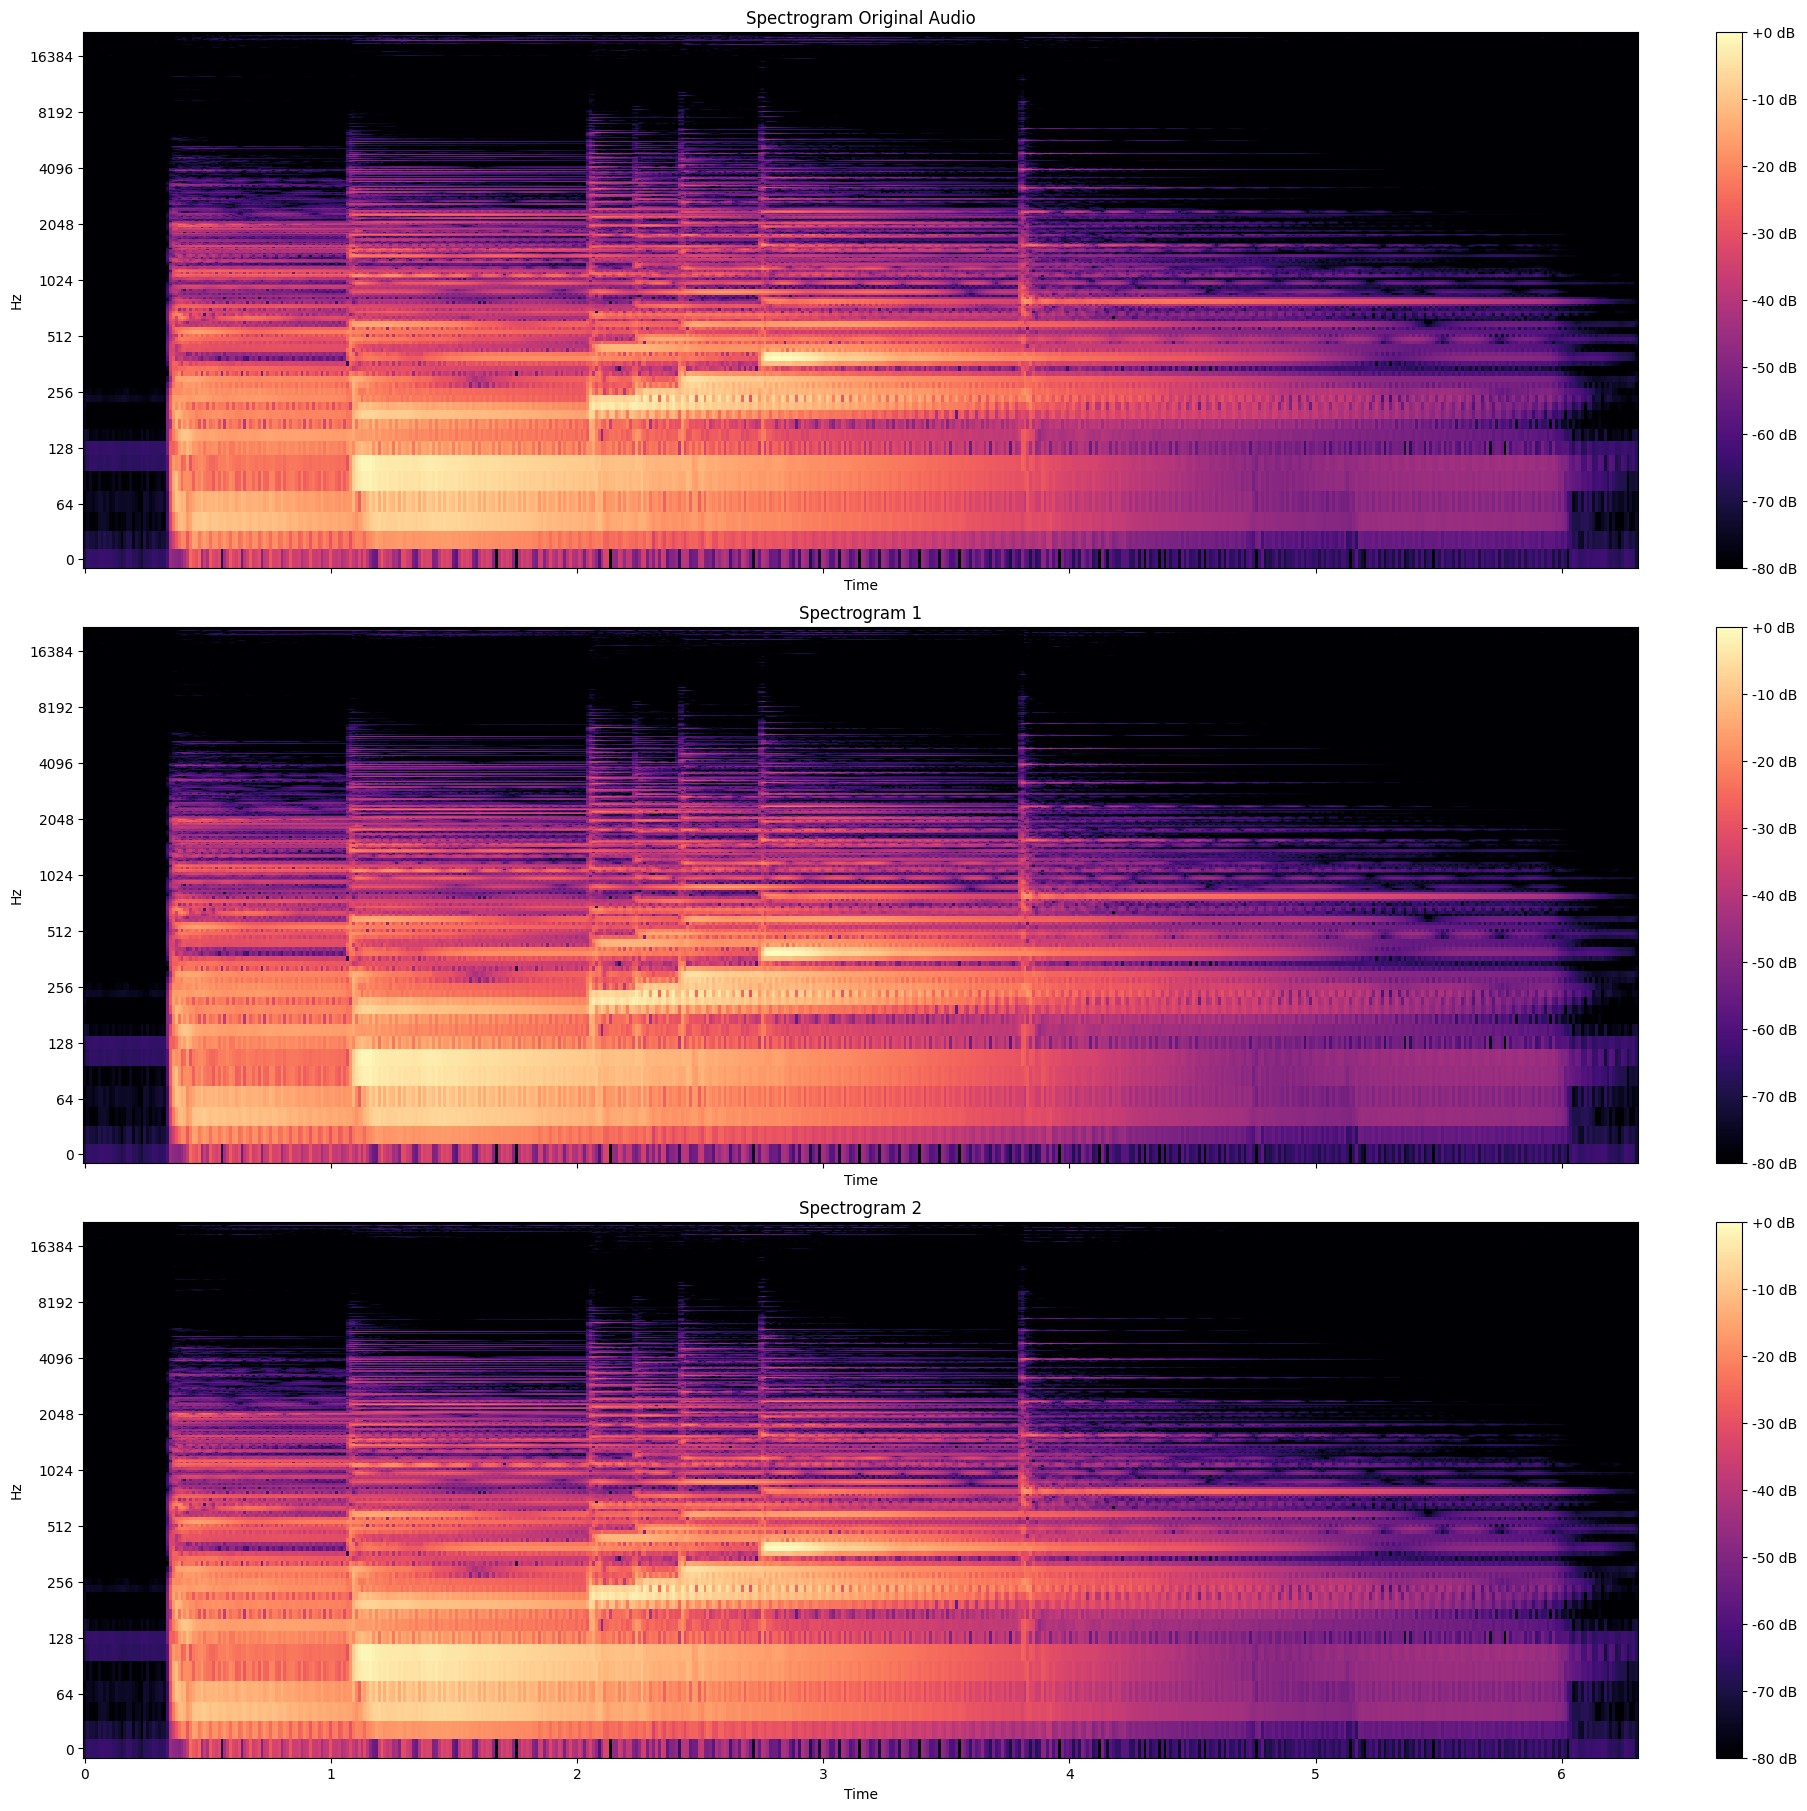

In [35]:
fig, ax = plt.subplots(nrows=len(namesList), ncols=1, figsize=(18, 18), sharex=True, sharey=True, layout='constrained')
specshow_kwargs = dict(sr=sr, x_axis='time', y_axis='log', cmap='magma')

for i, dbStft in enumerate(dbList):
    img = librosa.display.specshow(dbStft, ax=ax[i], **specshow_kwargs)
    fig.colorbar(img, ax=ax[i], format='%+2.0f dB')
    ax[i].set_title(f'Spectrogram {namesList[i]}')

fig.savefig('spectrograms/test_spectrograms.png', dpi=150, bbox_inches='tight')


#plt.figure(figsize=(10, 6))
#librosa.display.specshow(stft_db, sr=sr, x_axis='time', y_axis='hz')
#plt.colorbar(format='%+2.0f dB')#capire per quale motivo dobbiamo utilizare i decibel
#plt.title('Spectrogram')
plt.show()

In [15]:
import matplotlib.pyplot as plt
import gc

plt.close('all') # Closes all hidden figure windows
gc.collect()     # Forces Python to run garbage collection and free RAM

20762